# Experiment 3: Black-Scholes Option Pricing Model and Sensitivity Analysis

## Aim
1. To understand the Black-Scholes model for pricing European call options.
2. To analyze the sensitivity of option price with respect to volatility, time to maturity, and interest rate.
3. To visualize the impact of key parameters on option pricing.

## Theory
The Black-Scholes model calculates the theoretical price of European call options using:

**c = S*N(d1) - K*e^(-rt)*N(d2)**

Where:
- $d_1 = \frac{\ln(S/K) + (r + 0.5σ^2)T}{σ\sqrt{T}}$
- $d_2 = d_1 - σ\sqrt{T}$
- S = Current stock price
- K = Strike price
- T = Time to maturity (in years)
- r = Risk-free interest rate
- σ = Volatility of the stock
- N(d) = Cumulative distribution function (CDF) of standard normal distribution

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4)

In [2]:
# Black-Scholes Model Implementation
def black_scholes_call(S, K, T, r, sigma):
    """
    Calculate European call option price using Black-Scholes formula
    
    Parameters:
    S: Current stock price
    K: Strike price
    T: Time to maturity (in years)
    r: Risk-free interest rate
    sigma: Volatility
    
    Returns:
    c: Call option price
    d1, d2: Intermediate values
    """
    
    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate cumulative normal distribution values
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    
    # Calculate call option price
    call_price = S * N_d1 - K * np.exp(-r * T) * N_d2
    
    return call_price, d1, d2, N_d1, N_d2

## Step 1: Calculate Call Option Price with Given Data

**Given Data:**
- Stock Price (S): 60
- Strike Price (K): 56
- Time to Maturity (T): 0.5 years
- Risk-Free Rate (r): 0.14 (14%)
- Volatility (σ): 0.3 (30%)

In [3]:
# Given data
S = 60        # Stock price
K = 56        # Strike price
T = 0.5       # Time to maturity (years)
r = 0.14      # Risk-free rate
sigma = 0.3   # Volatility

# Calculate using Black-Scholes model
call_price, d1, d2, N_d1, N_d2 = black_scholes_call(S, K, T, r, sigma)

# Display results
print("=" * 60)
print("BLACK-SCHOLES OPTION PRICING CALCULATION")
print("=" * 60)
print(f"\nInput Parameters:")
print(f"  Stock Price (S):           ${S}")
print(f"  Strike Price (K):          ${K}")
print(f"  Time to Maturity (T):      {T} years")
print(f"  Risk-Free Rate (r):        {r*100}%")
print(f"  Volatility (σ):            {sigma*100}%")

print(f"\nIntermediate Calculations:")
print(f"  d1:                        {d1:.5f}")
print(f"  d2:                        {d2:.5f}")
print(f"  N(d1):                     {N_d1:.5f}")
print(f"  N(d2):                     {N_d2:.5f}")

# Manual step-by-step verification
pv_exercise = K * np.exp(-r * T)
component1 = S * N_d1
component2 = pv_exercise * N_d2

print(f"\nStep-by-Step Verification:")
print(f"  S * N(d1):                 ${component1:.2f}")
print(f"  PV of Strike Price:        ${pv_exercise:.2f}")
print(f"  PV of Strike * N(d2):      ${component2:.2f}")
print(f"\nFinal Result:")
print(f"  Call Option Price (c):     ${call_price:.2f}")
print("=" * 60)

BLACK-SCHOLES OPTION PRICING CALCULATION

Input Parameters:
  Stock Price (S):           $60
  Strike Price (K):          $56
  Time to Maturity (T):      0.5 years
  Risk-Free Rate (r):        14.000000000000002%
  Volatility (σ):            30.0%

Intermediate Calculations:
  d1:                        0.76128
  d2:                        0.54915
  N(d1):                     0.77676
  N(d2):                     0.70855

Step-by-Step Verification:
  S * N(d1):                 $46.61
  PV of Strike Price:        $52.21
  PV of Strike * N(d2):      $37.00

Final Result:
  Call Option Price (c):     $9.61


## Step 2: Sensitivity Analysis

### 2.1 Volatility Sensitivity (σ from 10% to 50%)

In [5]:
# Volatility Sensitivity Analysis
volatility_range = np.linspace(0.10, 0.50, 20)
call_prices_volatility = []

for vol in volatility_range:
    price, _, _, _, _ = black_scholes_call(S, K, T, r, vol)
    call_prices_volatility.append(price)

# Display volatility sensitivity table
print("\nVolatility Sensitivity Analysis:")
print("-" * 40)
print(f"{'Volatility':<15} {'Call Price':<10}")
print("-" * 40)
for vol, price in zip(volatility_range, call_prices_volatility):
    print(f"{vol*100:>6.1f}%        ${price:>7.2f}")
print("-" * 40)

# Key insight
print(f"\nKey Finding: Option price increases from ${min(call_prices_volatility):.2f} to ${max(call_prices_volatility):.2f}")
print(f"as volatility increases from {volatility_range[0]*100:.0f}% to {volatility_range[-1]*100:.0f}%")


Volatility Sensitivity Analysis:
----------------------------------------
Volatility      Call Price
----------------------------------------
  10.0%        $   7.82
  12.1%        $   7.89
  14.2%        $   8.00
  16.3%        $   8.14
  18.4%        $   8.32
  20.5%        $   8.52
  22.6%        $   8.74
  24.7%        $   8.97
  26.8%        $   9.22
  28.9%        $   9.48
  31.1%        $   9.74
  33.2%        $  10.02
  35.3%        $  10.30
  37.4%        $  10.58
  39.5%        $  10.87
  41.6%        $  11.16
  43.7%        $  11.46
  45.8%        $  11.76
  47.9%        $  12.06
  50.0%        $  12.36
----------------------------------------

Key Finding: Option price increases from $7.82 to $12.36
as volatility increases from 10% to 50%


### 2.2 Time to Maturity Sensitivity (T from 0.1 to 2 years)

In [6]:
# Time to Maturity Sensitivity Analysis
time_range = np.linspace(0.1, 2.0, 20)
call_prices_time = []

for t in time_range:
    price, _, _, _, _ = black_scholes_call(S, K, t, r, sigma)
    call_prices_time.append(price)

# Display time sensitivity table
print("\nTime to Maturity Sensitivity Analysis:")
print("-" * 40)
print(f"{'Time (years)':<15} {'Call Price':<10}")
print("-" * 40)
for t, price in zip(time_range, call_prices_time):
    print(f"{t:>6.2f}          ${price:>7.2f}")
print("-" * 40)

# Key insight
print(f"\nKey Finding: Option price ranges from ${min(call_prices_time):.2f} to ${max(call_prices_time):.2f}")
print(f"as time increases from {time_range[0]:.1f} to {time_range[-1]:.1f} years")


Time to Maturity Sensitivity Analysis:
----------------------------------------
Time (years)    Call Price
----------------------------------------
  0.10          $   5.35
  0.20          $   6.60
  0.30          $   7.69
  0.40          $   8.68
  0.50          $   9.61
  0.60          $  10.48
  0.70          $  11.32
  0.80          $  12.12
  0.90          $  12.89
  1.00          $  13.63
  1.10          $  14.35
  1.20          $  15.06
  1.30          $  15.74
  1.40          $  16.41
  1.50          $  17.06
  1.60          $  17.69
  1.70          $  18.32
  1.80          $  18.93
  1.90          $  19.53
  2.00          $  20.11
----------------------------------------

Key Finding: Option price ranges from $5.35 to $20.11
as time increases from 0.1 to 2.0 years


### 2.3 Interest Rate Sensitivity (r from 1% to 10%)

In [7]:
# Interest Rate Sensitivity Analysis
rate_range = np.linspace(0.01, 0.10, 20)
call_prices_rate = []

for rate in rate_range:
    price, _, _, _, _ = black_scholes_call(S, K, T, rate, sigma)
    call_prices_rate.append(price)

# Display interest rate sensitivity table
print("\nInterest Rate Sensitivity Analysis:")
print("-" * 40)
print(f"{'Rate':<15} {'Call Price':<10}")
print("-" * 40)
for rate, price in zip(rate_range, call_prices_rate):
    print(f"{rate*100:>6.1f}%        ${price:>7.2f}")
print("-" * 40)

# Key insight
print(f"\nKey Finding: Option price increases from ${min(call_prices_rate):.2f} to ${max(call_prices_rate):.2f}")
print(f"as interest rate increases from {rate_range[0]*100:.0f}% to {rate_range[-1]*100:.0f}%")


Interest Rate Sensitivity Analysis:
----------------------------------------
Rate            Call Price
----------------------------------------
   1.0%        $   7.32
   1.5%        $   7.40
   1.9%        $   7.48
   2.4%        $   7.56
   2.9%        $   7.64
   3.4%        $   7.72
   3.8%        $   7.80
   4.3%        $   7.88
   4.8%        $   7.96
   5.3%        $   8.04
   5.7%        $   8.13
   6.2%        $   8.21
   6.7%        $   8.29
   7.2%        $   8.37
   7.6%        $   8.46
   8.1%        $   8.54
   8.6%        $   8.62
   9.1%        $   8.71
   9.5%        $   8.79
  10.0%        $   8.88
----------------------------------------

Key Finding: Option price increases from $7.32 to $8.88
as interest rate increases from 1% to 10%


## Step 3: Visual Analysis

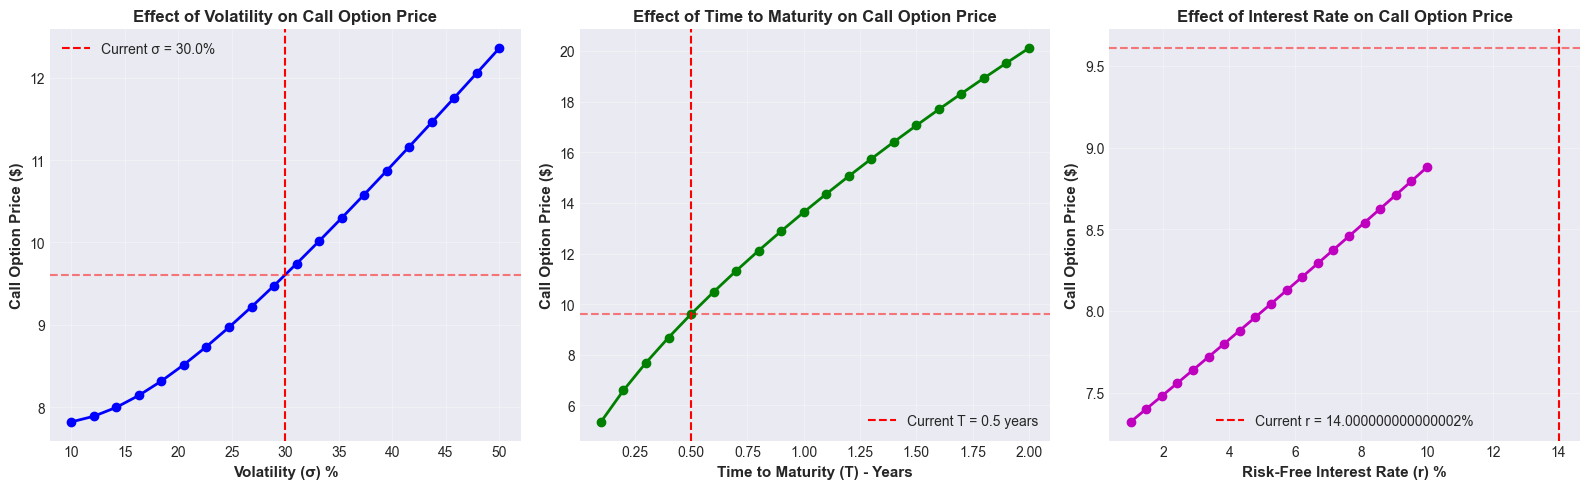


Plots saved as 'black_scholes_sensitivity.png'


In [8]:
# Create visualization plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Volatility Effect
axes[0].plot(volatility_range * 100, call_prices_volatility, 'b-o', linewidth=2, markersize=6)
axes[0].axvline(x=sigma*100, color='r', linestyle='--', label=f'Current σ = {sigma*100}%')
axes[0].axhline(y=call_price, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Volatility (σ) %', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Call Option Price ($)', fontsize=11, fontweight='bold')
axes[0].set_title('Effect of Volatility on Call Option Price', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Time to Maturity Effect
axes[1].plot(time_range, call_prices_time, 'g-o', linewidth=2, markersize=6)
axes[1].axvline(x=T, color='r', linestyle='--', label=f'Current T = {T} years')
axes[1].axhline(y=call_price, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time to Maturity (T) - Years', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Call Option Price ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Effect of Time to Maturity on Call Option Price', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Interest Rate Effect
axes[2].plot(rate_range * 100, call_prices_rate, 'm-o', linewidth=2, markersize=6)
axes[2].axvline(x=r*100, color='r', linestyle='--', label=f'Current r = {r*100}%')
axes[2].axhline(y=call_price, color='r', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Risk-Free Interest Rate (r) %', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Call Option Price ($)', fontsize=11, fontweight='bold')
axes[2].set_title('Effect of Interest Rate on Call Option Price', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('black_scholes_sensitivity.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nPlots saved as 'black_scholes_sensitivity.png'")

In [9]:
# Summary Analysis Table
print("\n" + "=" * 70)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 70)

summary_data = {
    'Parameter': ['Volatility (σ)', 'Time to Maturity (T)', 'Interest Rate (r)'],
    'Range': ['10% - 50%', '0.1 - 2.0 years', '1% - 10%'],
    'Min Price': [f'${min(call_prices_volatility):.2f}', 
                  f'${min(call_prices_time):.2f}', 
                  f'${min(call_prices_rate):.2f}'],
    'Max Price': [f'${max(call_prices_volatility):.2f}', 
                  f'${max(call_prices_time):.2f}', 
                  f'${max(call_prices_rate):.2f}'],
    'Price Change': [f'${max(call_prices_volatility) - min(call_prices_volatility):.2f}',
                     f'${max(call_prices_time) - min(call_prices_time):.2f}',
                     f'${max(call_prices_rate) - min(call_prices_rate):.2f}'],
    'Relationship': ['Positive', 'Positive', 'Positive']
}

df_summary = pd.DataFrame(summary_data)
print("\n", df_summary.to_string(index=False))
print("\n" + "=" * 70)


SENSITIVITY ANALYSIS SUMMARY

            Parameter           Range Min Price Max Price Price Change Relationship
      Volatility (σ)       10% - 50%     $7.82    $12.36        $4.54     Positive
Time to Maturity (T) 0.1 - 2.0 years     $5.35    $20.11       $14.76     Positive
   Interest Rate (r)        1% - 10%     $7.32     $8.88        $1.56     Positive



## Step 4: Conclusions

### Key Findings:

1. **Volatility Effect (σ):**
   - Call option prices show a strong positive relationship with volatility
   - As volatility increases from 10% to 50%, the call option price increases significantly
   - This is because higher volatility increases the probability of larger price movements, benefiting call holders
   - The relationship is non-linear, with greater sensitivity at lower volatility levels

2. **Time to Maturity Effect (T):**
   - Longer time to maturity generally results in higher call option prices
   - This is due to the increased opportunity for the stock price to move above the strike price
   - The relationship shows diminishing returns - the benefit of additional time decreases over time
   - However, there is always a positive relationship between time and option value

3. **Interest Rate Effect (r):**
   - Call option prices increase with rising interest rates
   - Higher interest rates reduce the present value of the strike price to be paid at expiration
   - Therefore, the discounted strike price becomes relatively lower, making the option more valuable
   - This effect is more subtle compared to volatility and time effects

### Black-Scholes Model Applications in Finance:

1. **Portfolio Hedging:** Investors use option pricing to determine appropriate hedge ratios
2. **Options Trading:** Traders identify mispriced options by comparing market prices with theoretical prices
3. **Risk Management:** Financial institutions use the model to assess and manage options portfolios
4. **Valuation:** The model provides a theoretical benchmark for option values in markets

### Model Limitations:

- Assumes European-style options (can only be exercised at maturity)
- Assumes no dividends during the option's life
- Constant volatility assumption (volatility varies in real markets)
- Frictionless markets with no transaction costs
- Perfect divisibility of assets

### Practical Implications:

The sensitivity analysis reveals that traders should monitor volatility levels closely, as even small changes can significantly impact option valuations. Additionally, time decay (theta) becomes increasingly important as expiration approaches, and interest rate changes, while less dramatic, should not be ignored in portfolio management.